<a href="https://colab.research.google.com/github/Sofiosu24/IA_training_classification_realWaste/blob/Fase3_fineTuning_model/RealWaste_Modelo_Preentrenado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
%cd "/content/drive/MyDrive/realwaste_main/RealWaste"
!ls

/content/drive/MyDrive/realwaste_main/RealWaste
test  train  validation


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
base_dir = '/content/drive/MyDrive/realwaste_main/RealWaste'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

print("Train:", train_dir)
print("Validation:", validation_dir)
print("Test:", test_dir)

Train: /content/drive/MyDrive/realwaste_main/RealWaste/train
Validation: /content/drive/MyDrive/realwaste_main/RealWaste/validation
Test: /content/drive/MyDrive/realwaste_main/RealWaste/test


In [6]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range = 40,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)


In [7]:
# Tamaño al que vamos a redimensionar todas las imágenes
target_size = (224, 224)
batch_size = 20

# Generador de entrenamiento
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = target_size,
    batch_size = batch_size,
    class_mode = 'categorical')

# Generador de validación
val_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size = target_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle=False)

Found 3323 images belonging to 9 classes.
Found 715 images belonging to 9 classes.


In [9]:
# ETAPA 1: Congelado
from tensorflow.keras.metrics import Precision, Recall, F1Score, CategoricalAccuracy
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers

# Base preentrenada en ImageNet, sin la capa de clasificación final
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),   # flatten
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(9, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-3),
    metrics=[
        CategoricalAccuracy(name='acc'),
        Precision(name='precision'),
        Recall(name='recall'),
        F1Score(average='macro', name='f1_score')
    ]
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

# Path del checkpoint de v4
checkpoint_path = '/content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4.keras'

checkpoint_best = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,
    save_freq='epoch',
    monitor='val_acc',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_acc',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

cls = train_generator.classes
weights = compute_class_weight('balanced', classes=np.unique(cls), y=cls)
class_weight = dict(enumerate(weights))
print(class_weight)

{0: np.float64(1.1466528640441684), 1: np.float64(1.286488579171506), 2: np.float64(1.2558578987150415), 3: np.float64(0.6676712879244525), 4: np.float64(1.067116249197174), 5: np.float64(1.0549206349206348), 6: np.float64(0.5733264320220842), 7: np.float64(1.6631631631631631), 8: np.float64(1.2105646630236795)}


In [ ]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weight,
    callbacks=[checkpoint_best, early_stop])

Epoch 1/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - acc: 0.3666 - f1_score: 0.3639 - loss: 1.8131 - precision: 0.5030 - recall: 0.2015
Epoch 1: val_acc improved from None to 0.53986, saving model to /content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4.keras
167/167 ━━━━━━━━━━━━━━━━━━━━ 1277s 8s/step - acc: 0.4902 - f1_score: 0.4849 - loss: 1.4286 - precision: 0.6523 - recall: 0.3331 - val_acc: 0.5399 - val_f1_score: 0.5503 - val_loss: 1.2779 - val_precision: 0.6872 - val_recall: 0.3748
Epoch 2/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - acc: 0.6474 - f1_score: 0.6463 - loss: 0.9719 - precision: 0.7630 - recall: 0.5346
Epoch 2: val_acc improved from 0.53986 to 0.60979, saving model to /content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4.keras
167/167 ━━━

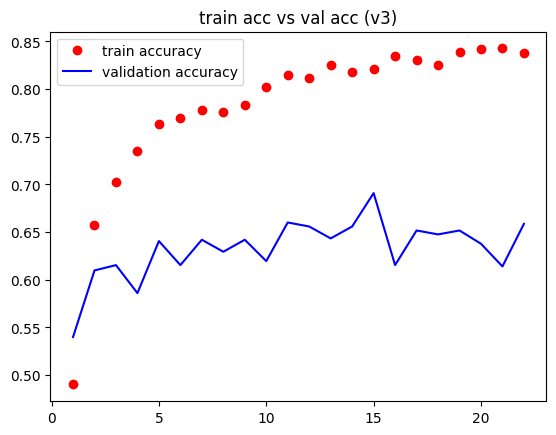

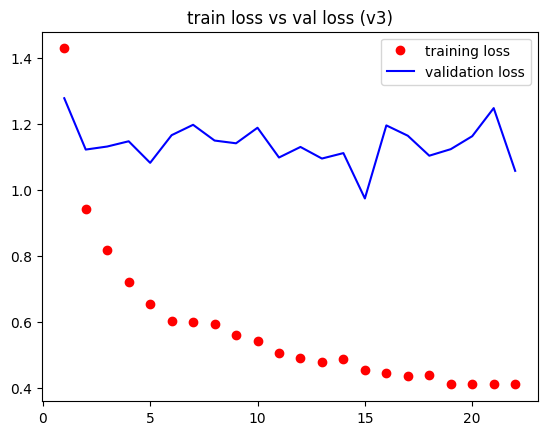

In [ ]:
acc = [0.4902, 0.6578, 0.7024, 0.7355, 0.7629, 0.7698, 0.7785, 0.7761, 0.7836, 0.8023, 0.8149, 0.8113, 0.8255, 0.8179, 0.8215, 0.8345, 0.8309, 0.8249, 0.8393, 0.8420, 0.8426, 0.8378]
val_acc = [0.5399, 0.6098, 0.6154, 0.5860, 0.6406, 0.6154, 0.6420, 0.6294, 0.6420, 0.6196, 0.6601, 0.6559, 0.6434, 0.6559, 0.6909, 0.6154, 0.6517, 0.6476, 0.6517, 0.6378, 0.6140, 0.6587]
loss = [1.4286, 0.9434, 0.8193, 0.7209, 0.6544, 0.6021, 0.5993, 0.5926, 0.5612, 0.5429, 0.5073, 0.4912, 0.4782, 0.4871, 0.4549, 0.4466, 0.4354, 0.4403, 0.4131, 0.4122, 0.4108, 0.4132]
val_loss = [1.2779, 1.1224, 1.1316, 1.1475, 1.0822, 1.1660, 1.1974, 1.1497, 1.1414, 1.1885, 1.0983, 1.1303, 1.0952, 1.1117, 0.9743, 1.1956, 1.1643, 1.1038, 1.1236, 1.1629, 1.2480, 1.0579]

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, 'ro', label='train accuracy')
plt.plot(epochs, val_acc, 'b', label='validation accuracy')
plt.title('train acc vs val acc (v3)')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'ro', label='training loss')
plt.plot(epochs, val_loss, 'b', label='validation loss')
plt.title('train loss vs val loss (v3)')
plt.legend()

plt.show()

In [ ]:
from tensorflow.keras.models import load_model

# Cargar el mejor modelo guardado por el checkpoint v4
model = load_model('/content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4.keras')

Found 715 images belonging to 9 classes.
36/36 ━━━━━━━━━━━━━━━━━━━━ 395s 11s/step


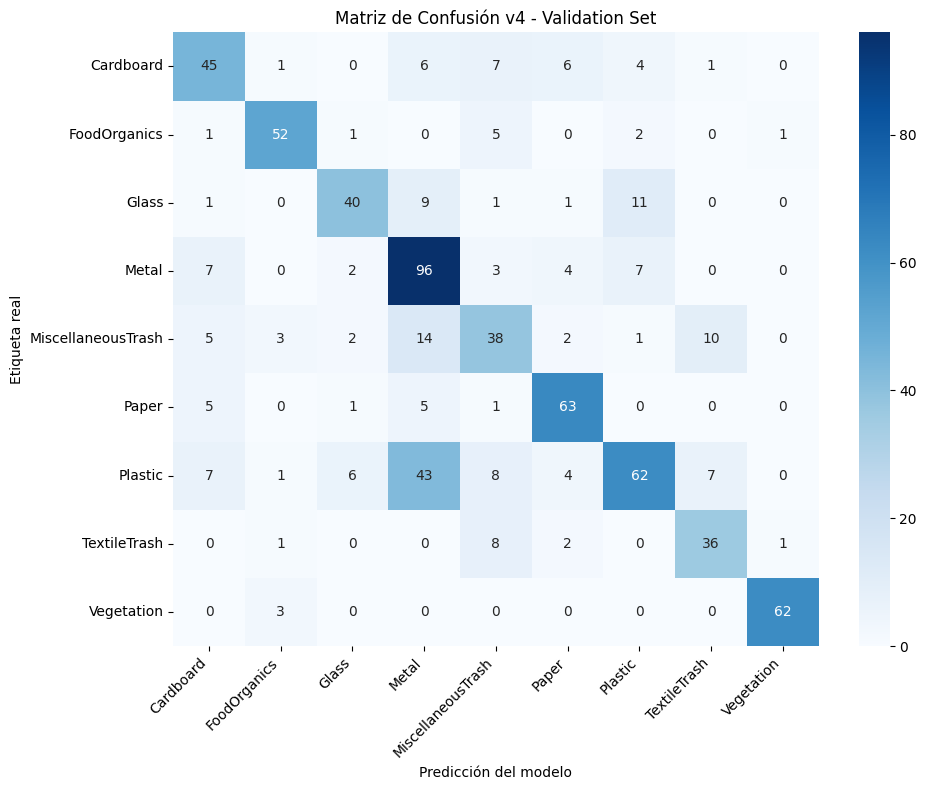

                    precision    recall  f1-score   support

         Cardboard       0.63      0.64      0.64        70
      FoodOrganics       0.85      0.84      0.85        62
             Glass       0.77      0.63      0.70        63
             Metal       0.55      0.81      0.66       119
MiscellaneousTrash       0.54      0.51      0.52        75
             Paper       0.77      0.84      0.80        75
           Plastic       0.71      0.45      0.55       138
      TextileTrash       0.67      0.75      0.71        48
        Vegetation       0.97      0.95      0.96        65

          accuracy                           0.69       715
         macro avg       0.72      0.71      0.71       715
      weighted avg       0.70      0.69      0.69       715



In [ ]:
# Generator de evaluación con shuffle=False
eval_val_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=20,
    class_mode='categorical',
    shuffle=False
)

# Predicciones
predictions = model.predict(eval_val_generator)
classes_x = np.argmax(predictions, axis=1)

# Etiquetas verdaderas
val_labels = eval_val_generator.classes

# Matriz de confusión
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(val_labels, classes_x)

# Nombres de clases
class_names = list(eval_val_generator.class_indices.keys())

# Visualizar
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción del modelo')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión v4 - Validation Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
from sklearn.metrics import classification_report
print(classification_report(val_labels, classes_x, target_names=class_names))

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4.keras')

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=20,
    class_mode='categorical',
    shuffle=False)

results = model.evaluate(test_generator)
test_loss = results[0]   # loss siempre es el primero
test_acc = results[1]    # acc es el segundo
print('\ntest acc:', test_acc)
print('test loss:', test_loss)

Found 714 images belonging to 9 classes.
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - acc: 0.6583 - f1_score: 0.6610 - loss: 1.0464 - precision: 0.7240 - recall: 0.6134

test acc: 0.6582633256912231
test loss: 1.0463685989379883


In [ ]:
# Reporte detallado por clase
predictions = model.predict(test_generator)
classes_x = np.argmax(predictions, axis=1)
test_labels = test_generator.classes

from sklearn.metrics import classification_report
print(classification_report(test_labels, classes_x,
      target_names=list(test_generator.class_indices.keys())))

36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 211ms/step
                    precision    recall  f1-score   support

         Cardboard       0.68      0.90      0.78        69
      FoodOrganics       0.75      0.77      0.76        62
             Glass       0.68      0.43      0.52        63
             Metal       0.61      0.74      0.67       118
MiscellaneousTrash       0.42      0.35      0.38        74
             Paper       0.71      0.84      0.77        75
           Plastic       0.62      0.49      0.55       139
      TextileTrash       0.66      0.69      0.67        48
        Vegetation       0.85      0.85      0.85        66

          accuracy                           0.66       714
         macro avg       0.66      0.67      0.66       714
      weighted avg       0.65      0.66      0.65       714



In [ ]:
import shutil
shutil.copy(
    '/content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4.keras',
    '/content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4_etapa1.keras'
)
print("Copia de seguridad creada")

Copia de seguridad creada


In [ ]:
# ETAPA 2: FINE-TUNING

# Descongelar la base
base_model.trainable = True

# Congelar las primeras 130 capas, afinar solo las últimas
for layer in base_model.layers[:130]:
    layer.trainable = False

# Recompilar con learning rate MUY bajo (clave: 100x menor que la etapa 1)
model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=[
        CategoricalAccuracy(name='acc'),
        Precision(name='precision'),
        Recall(name='recall'),
        F1Score(average='macro', name='f1_score')
    ]
)

# Continuar entrenando desde donde quedó la etapa 1
history_ft = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weight,
    callbacks=[checkpoint_best, early_stop])

Epoch 1/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - acc: 0.8297 - f1_score: 0.8314 - loss: 0.4540 - precision: 0.8783 - recall: 0.7942 
Epoch 1: val_acc improved from None to 0.68392, saving model to /content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4.keras
167/167 ━━━━━━━━━━━━━━━━━━━━ 1969s 12s/step - acc: 0.8354 - f1_score: 0.8403 - loss: 0.4335 - precision: 0.8822 - recall: 0.8002 - val_acc: 0.6839 - val_f1_score: 0.7027 - val_loss: 0.9868 - val_precision: 0.7538 - val_recall: 0.6294
Epoch 2/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - acc: 0.8457 - f1_score: 0.8494 - loss: 0.4003 - precision: 0.8903 - recall: 0.8016
Epoch 2: val_acc improved from 0.68392 to 0.68531, saving model to /content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4.keras
167/167 

In [8]:
from tensorflow.keras.models import load_model
m = load_model('/content/drive/MyDrive/realwaste_main/checkpoints/best_model_v4.keras')
m.evaluate(val_generator)

36/36 ━━━━━━━━━━━━━━━━━━━━ 174s 5s/step - acc: 0.6909 - f1_score: 0.7087 - loss: 0.9743 - precision: 0.7533 - recall: 0.6364


[0.974298894405365,
 0.6909090876579285,
 0.753311276435852,
 0.6363636255264282,
 0.7087046504020691]